1. Autoencoder is a type of self supervision models
2. Input → Encoder → Latent Space → Decoder → Output
3. An autoencoder is a neural network that learns to compress data and reconstruct it.

In [19]:
import torch
from torch import nn
import  torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets
from torchvision.datasets import MNIST
from torchvision import transforms
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

In [20]:
D = 28*28 # dim of Mnist dataset
n= 2 # latent space dim
C = 1 # channels (mnist -> grayscale)
classes = 10 # number of classes

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Autoencoder is self supervised ( no labels )

In [22]:
class AutoEncoderDataset(Dataset):
  """takes a dataset (x,y) returns (x,x)"""
  def __init__(self,dataset):
    self.dataset = dataset

  def __len__(self):
    return len(self.dataset)
  def __getitem__(self,idx):
    x,y = self.dataset[idx]
    return x,x

In [23]:
train_data = AutoEncoderDataset(MNIST('./',train=True,download=True,transform=transforms.ToTensor()))
test_data_xy = MNIST('./',train=False,download=True,transform=transforms.ToTensor())
test_data_xx = AutoEncoderDataset(test_data_xy)

# DataLoader : loads data from a dataset and serves it to your model in batches
train_loader = DataLoader(train_data,batch_size=128,shuffle=True)
test_loader = DataLoader(test_data_xx,batch_size=128)

In [24]:
x,l = next(iter(test_data_xy))
x.shape , l

(torch.Size([1, 28, 28]), 7)

In [25]:
x,x_2 = next(iter(test_data_xx))
x.shape , x_2.shape

(torch.Size([1, 28, 28]), torch.Size([1, 28, 28]))

## Building block of autoencoder

In [26]:
from torch.nn.modules.batchnorm import BatchNorm1d
def get_layer(in_size,out_size):
  "It taks input size and transform it to the out size"
  return nn.Sequential(
      nn.Linear(in_size,out_size),
      nn.BatchNorm1d(out_size), # normalizes the activations of a layer
      nn.ReLU()
  )

In [27]:
# cutom pytorch layer

class View(nn.Module):
  def __init__(self,*shape):
    super().__init__()
    self.shape = shape
  def forward(self,input):
    return input.view(*self.shape) # view reshapes a tensor without changing its data

In [28]:
auto_encoder = nn.Sequential(
    nn.Flatten() , #784 = 28*28
    get_layer(D,D//2),
    get_layer(D//2,D//3),
    get_layer(D//3,D//4),
    nn.Linear(D//4,n)
)

auto_decoder = nn.Sequential(
    get_layer(2,D//4),
    get_layer(D//4,D//3),
    get_layer(D//3,D//2),
    nn.Linear(D//2,D),
    View(-1,1,28,28)
)

In [29]:
auto_encode_decode = nn.Sequential(
    auto_encoder,
    auto_decoder
)

In [30]:
from tqdm.autonotebook import tqdm
import time
import pandas as pd

def run_epoch(model, optimizer, data_loader, loss_func, device, results, score_funcs, prefix="", desc=None):
    """
    model -- the PyTorch model / "Module" to run for one epoch
    optimizer -- the object that will update the weights of the network
    data_loader -- DataLoader object that returns tuples of (input, label) pairs.
    loss_func -- the loss function that takes in two arguments, the model outputs and the labels, and returns a score
    device -- the compute lodation to perform training
    score_funcs -- a dictionary of scoring functions to use to evalue the performance of the model
    prefix -- a string to pre-fix to any scores placed into the _results_ dictionary.
    desc -- a description to use for the progress bar.
    """
    running_loss = []
    y_true = []
    y_pred = []
    start = time.time()

    for inputs,labels in tqdm(data_loader, desc=desc, leave=False):
        inputs = moveTo(inputs, device)
        labels = moveTo(labels, device)

        y_hat = model(inputs)

        loss = loss_func(y_hat,labels)

        if model.training :
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()
        running_loss.append(loss.item())
        if len(score_funcs) > 0 and isinstance(labels, torch.Tensor):
            labels = labels.detach().cpu().numpy()
            y_hat = y_hat.detach().cpu().numpy()
            #add to predictions so far
            y_true.extend(labels.tolist())
            y_pred.extend(y_hat.tolist())
    #end training epoch
    end = time.time()
    y_pred = np.asarray(y_pred)
    if len(y_pred.shape) == 2 and y_pred.shape[1] > 1: #We have a classification problem, convert to labels
        y_pred = np.argmax(y_pred, axis=1)
    #Else, we assume we are working on a regression problem

    results[prefix + " loss"].append( np.mean(running_loss) )
    for name, score_func in score_funcs.items():
        try:
            results[prefix + " " + name].append( score_func(y_true, y_pred) )
        except:
            results[prefix + " " + name].append(float("NaN"))
    return end-start #time spent on epoch

def moveTo(obj, device):
    """
    obj: the python object to move to a device, or to move its contents to a device
    device: the compute device to move objects to
    """
    if hasattr(obj, "to"):
        return obj.to(device)
    elif isinstance(obj, list):
        return [moveTo(x, device) for x in obj]
    elif isinstance(obj, tuple):
        return tuple(moveTo(list(obj), device))
    elif isinstance(obj, set):
        return set(moveTo(list(obj), device))
    elif isinstance(obj, dict):
        to_ret = dict()
        for key, value in obj.items():
            to_ret[moveTo(key, device)] = moveTo(value, device)
        return to_ret
    else:
        return obj

def train_network(
    model,
    loss_func,
    train_loader,
    val_loader=None,
    test_loader=None,
    score_funcs=None,
    epochs=50,
    device="cpu",
    checkpoint_file=None,
    lr_schedule=None,
    optimizer=None,
    disable_tqdm=False
    ):

    """Train simple neural networks

      Keyword arguments:
      model -- the PyTorch model / "Module" to train
      loss_func -- the loss function that takes in batch in two arguments, the model outputs and the labels, and returns a score
      train_loader -- PyTorch DataLoader object that returns tuples of (input, label) pairs.
      val_loader -- Optional PyTorch DataLoader to evaluate on after every epoch
      test_loader -- Optional PyTorch DataLoader to evaluate on after every epoch
      score_funcs -- A dictionary of scoring functions to use to evalue the performance of the model
      epochs -- the number of training epochs to perform
      device -- the compute lodation to perform training
      lr_schedule -- the learning rate schedule used to alter \eta as the model trains. If this is not None than the user must also provide the optimizer to use.
      optimizer -- the method used to alter the gradients for learning.

    """

    if score_funcs == None:
        score_funcs = {}
    to_track = ["epoch", "total time", "train loss"]
    if val_loader is not None :
      to_track.append("val loss")
    if test_loader is not None:
      to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if val_loader is not None:
            to_track.append("val " + eval_score )
        if test_loader is not None:
            to_track.append("test "+ eval_score )
    total_train_time = 0
    results = {}

    for item in to_track:
      results[item] = []

    if optimizer == None :
      optimizer = torch.optim.AdamW(model.parameters())
      del_opt = True
    else :
      del_opt = False
    model.to(device)

    for epoch in tqdm(range(epochs) , desc="Epoch", disable = disable_tqdm):
      model = model.train() # training mode
      total_train_time += run_epoch(model,optimizer,train_loader,loss_func,device,results,score_funcs,prefix="train", desc="training")

      results["epoch"].append( epoch )
      results["total time"].append( total_train_time )

      if val_loader is not None:
        model = model.eval()

        with torch.no_grad():
          run_epoch(model, optimizer, val_loader, loss_func, device, results, score_funcs, prefix="val", desc="Validating")
      if lr_schedule is not None :
          if isinstance(lr_schedule, torch.optim.lr_scheduler.ReduceLROnPlateau):
                lr_schedule.step(results["val loss"][-1])
          else:
                lr_schedule.step()

      if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")

      if checkpoint_file is not None:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'results' : results
                }, checkpoint_file)
    if del_opt:
        del optimizer

    return pd.DataFrame.from_dict(results)



<>:102: SyntaxWarning: invalid escape sequence '\e'
<>:102: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1871/2335655033.py:102: SyntaxWarning: invalid escape sequence '\e'
  lr_schedule -- the learning rate schedule used to alter \eta as the model trains. If this is not None than the user must also provide the optimizer to use.


In [31]:
train_network(
    model=auto_encode_decode,
    loss_func=nn.MSELoss(),
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10,
    device=device
)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/79 [00:00<?, ?it/s]

training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/79 [00:00<?, ?it/s]

...

training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/79 [00:00<?, ?it/s]

training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/79 [00:00<?, ?it/s]

,epoch,total time,train loss,test loss
0,0,8.178450,0.050139,0.043037
1,1,17.074065,0.043401,0.041399
2,2,26.061698,0.041876,0.040246
3,3,35.240705,0.041073,0.039045
4,4,43.985379,0.040278,0.038710
5,5,52.328612,0.039767,0.038490
6,6,61.334989,0.039347,0.038029
7,7,70.364451,0.038849,0.037525
8,8,79.375758,0.038509,0.037331
9,9,88.763653,0.038221,0.037375


In [32]:
def encode_batch(encoder,dataset_to_encode):
  projected = [] # encoded vectors
  labels = []

  encoder = encoder.eval()
  encoder = encoder.cpu()

  with torch.inference_mode(): # similar tp no_grad() , even more optimized7
    for x,y in DataLoader(dataset_to_encode,batch_size=128):
      z = encoder(x.cpu()) # latent vector
      projected.append(z.numpy())
      labels.append(y.cpu().numpy().ravel())

  projected = np.vstack(projected)
  labels = np.hstack(labels)

  return projected, labels



In [33]:
projected , labels = encode_batch(auto_encoder,test_data_xy)
projected.shape , projected.ndim

((10000, 2), 2)

<Axes: >

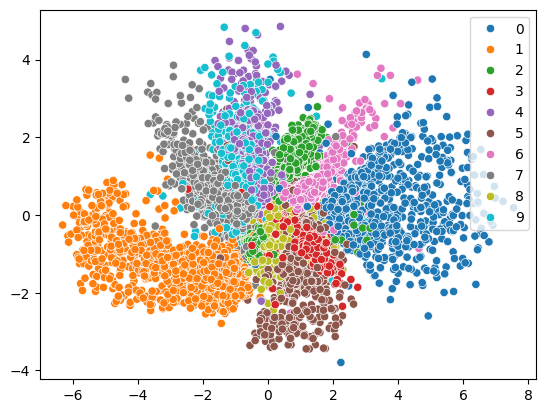

In [34]:
sns.scatterplot(
    x=projected[:,0],
    y=projected[:,1],
    hue=[str(l) for l in labels],
    hue_order=[str(i) for i in range(10)],
    legend="full")

In [35]:
def show_encode_decode(encode_decode,x):
    """
    encode_decode: the PyTorch Module that does the encoding and decoding steps at once
    x: the input to plot as is, and after encoding & decoding it
    """
    encode_decode = encode_decode.eval()
    encode_decode = encode_decode.cpu()
    with torch.inference_mode():
        x_recon = encode_decode(x.cpu())
        f , axarr = plt.subplots(1,2)
    axarr[0].imshow(x.numpy()[0,:])
    axarr[1].imshow(x_recon.numpy()[0,0,:])

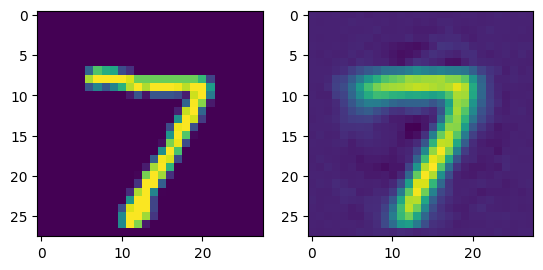

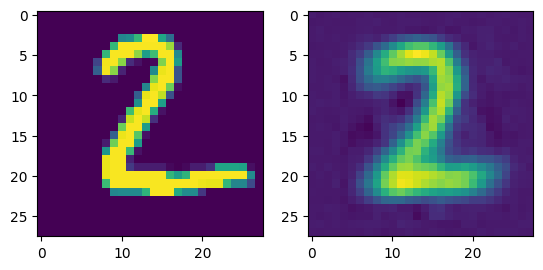

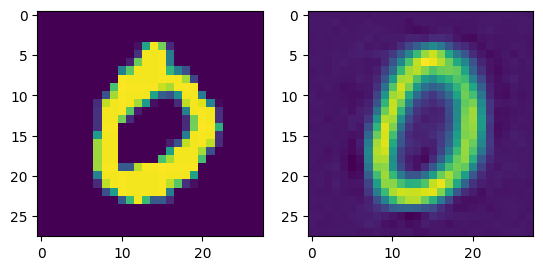

In [36]:
show_encode_decode(auto_encode_decode,test_data_xx[0][0])
show_encode_decode(auto_encode_decode,test_data_xx[1][0])
show_encode_decode(auto_encode_decode,test_data_xx[3][0])

In [37]:
normal = torch.distributions.Normal(0,0.5) # mean = 0 , std = 0.5
def addNoise(x,device='cpu'):
    """
    We will use this helper function to add noise to some data.
    x: the data we want to add noise to
    device: the CPU or GPU that the input is located on.
    """
    return x + normal.sample(sample_shape=torch.Size(x.shape)).to(device)

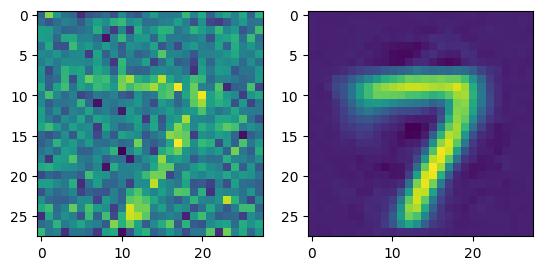

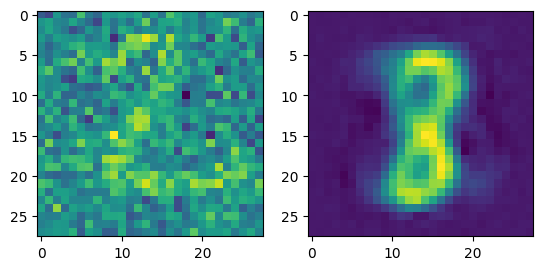

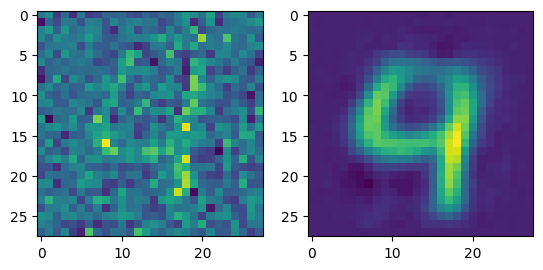

In [38]:
show_encode_decode(auto_encode_decode,addNoise(test_data_xy[0][0]))
show_encode_decode(auto_encode_decode,addNoise(test_data_xy[1][0]))
show_encode_decode(auto_encode_decode,addNoise(test_data_xy[4][0]))